Clusters: [[[2, 4], [2, 6]], [[8, 3], [5, 2], [6, 3], [4, 4]], [[5, 6], [4, 7], [6, 6], [5, 7]]]
Final Centroids: [[2.0, 5.0], [5.75, 3.0], [5.0, 6.5]]


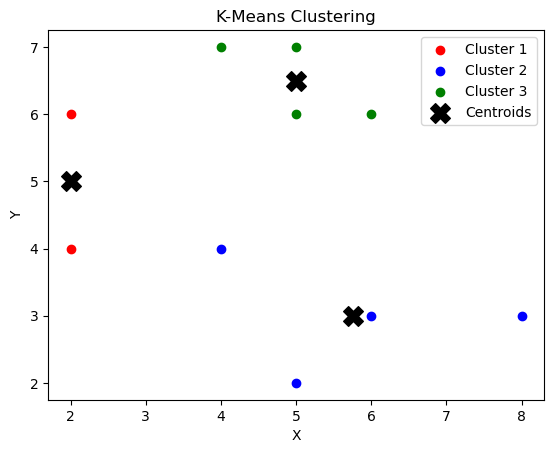

In [1]:
import math
import matplotlib.pyplot as plt

data = [
    [2,4], [2,6], [5,6], [4,7], [8,3],
    [6,6], [5,2], [5,7], [6,3], [4,4]
]

# Initial centroids
centroids = [[1,5], [4,1], [8,4]]

k = 3
max_iters = 10

def distance(p1, p2):
    return math.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)

for _ in range(max_iters):

    clusters = [[] for _ in range(k)]

    # Assign points to nearest centroid
    for point in data:
        distances = [distance(point, c) for c in centroids]
        cluster_index = distances.index(min(distances))
        clusters[cluster_index].append(point)

    # Compute new centroids
    new_centroids = []

    for cluster in clusters:
        x = sum(p[0] for p in cluster) / len(cluster)
        y = sum(p[1] for p in cluster) / len(cluster)
        new_centroids.append([x,y])

    if new_centroids == centroids:
        break

    centroids = new_centroids


print("Clusters:", clusters)
print("Final Centroids:", centroids)


# Plot clusters
colors = ['red','blue','green']

for i, cluster in enumerate(clusters):
    x = [p[0] for p in cluster]
    y = [p[1] for p in cluster]
    plt.scatter(x, y, color=colors[i], label=f'Cluster {i+1}')

# Plot centroids
cx = [c[0] for c in centroids]
cy = [c[1] for c in centroids]

plt.scatter(cx, cy, color='black', marker='X', s=200, label='Centroids')

plt.title("K-Means Clustering")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()
